In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import s3fs

from datetime import datetime, timezone
from loguru import logger
import matplotlib.pyplot as plt
import cmocean
from tqdm.auto import tqdm

In [5]:
RCA_s3_bucket = "ooi-data/"
fs = s3fs.S3FileSystem(anon=True)

def load_data(stream_name: str) -> xr.Dataset:
    zarr_store = fs.get_mapper(RCA_s3_bucket + stream_name)
    return xr.open_zarr(zarr_store, consolidated=True)

In [6]:
START_YEAR = 2015
SITES_DICT = (
    pd.read_csv("https://raw.githubusercontent.com/OOI-CabledArray/rca-data-tools/refs/heads/main/rca_data_tools/qaqc/params/sitesDictionary.csv")
    .set_index('refDes')
    .T.to_dict('series')
)

VARIABLE_MAP = (
    pd.read_csv("https://raw.githubusercontent.com/OOI-CabledArray/rca-data-tools/refs/heads/main/rca_data_tools/qaqc/params/variableMap.csv")
    .set_index('parameter')
    .T.to_dict('series')
)

In [7]:
PROFILER_SITES = {
    "oregon_shelf": {
        "ctd":       "CE04OSPS-SF01B-2A-CTDPFA107",
        "ph":        "CE04OSPS-SF01B-2B-PHSENA108",
        "pco2":      "CE04OSPS-SF01B-4F-PCO2WA102",
        "nutrients": "CE04OSPS-SF01B-4A-NUTNRA102",
    },
    "slope_base": {
        "ctd":       "RS01SBPS-SF01A-2A-CTDPFA102",
        "ph":        "RS01SBPS-SF01A-2D-PHSENA101",
        "pco2":      "RS01SBPS-SF01A-4F-PCO2WA101",
        "nutrients": "RS01SBPS-SF01A-4A-NUTNRA101",
    },
    "axial_base": {
        "ctd":       "RS03AXPS-SF03A-2A-CTDPFA302",
        "ph":        "RS03AXPS-SF03A-2D-PHSENA301",
        "pco2":      "RS03AXPS-SF03A-4F-PCO2WA301",
        "nutrients": "RS03AXPS-SF03A-4A-NUTNRA301",
    },
}

In [8]:
DOWNCAST_INSTRUMENTS = {"ph", "pco2"}

PRES_PARAMS = VARIABLE_MAP['pressure']['variableNames'].strip('"').split(",")

PARAM_TO_INSTRUMENT = {
    # ctd
    "sea_water_temperature":         "ctd",
    "sea_water_practical_salinity":  "ctd",
    "corrected_dissolved_oxygen":    "ctd",
    "sea_water_density":             "ctd",
    # nutrients
    "salinity_corrected_nitrate":    "nutrients",
    "nitrate_concentration":         "nutrients",
    # ph (downcast)
    "ph_seawater":                   "ph",
    # pco2 (downcast)
    "pco2_seawater":                 "pco2",
    "partial_pressure_co2_ssw":      "pco2",
    "xco2_atm":                      "pco2",
}

In [9]:
def load_regridding_inputs(
    site_dict: dict,
    params: list[str],
    append: bool = True,
) -> tuple[list[dict], pd.DataFrame]:

    now = datetime.now(timezone.utc)
    current_year = now.year
    years = [current_year] if append else list(range(START_YEAR, current_year + 1))

    site = site_dict["ctd"][:8]

    # group requested params by instrument key
    instrument_params: dict[str, list[str]] = {}
    for param in params:
        instr_key = PARAM_TO_INSTRUMENT.get(param)
        if instr_key is None:
            logger.warning(f"no instrument mapping for '{param}', skipping")
            continue
        instrument_params.setdefault(instr_key, []).append(param)

    # load each unique zarr store
    instrument_datasets: list[dict] = []
    for instr_key, instr_params in instrument_params.items():
        refdes = site_dict[instr_key]
        stream_name = SITES_DICT[refdes]['zarrFile']
        logger.info(f"loading zarr: {instr_key} ({refdes})")
        ds = load_data(stream_name)
        available = [v for v in PRES_PARAMS + instr_params if v in ds]
        instrument_datasets.append({
            "instrument": instr_key,
            "ds": ds[available],
            "params": [p for p in instr_params if p in ds],
            "is_downcast": instr_key in DOWNCAST_INSTRUMENTS,
        })

    logger.info("loading profile indices")
    all_indices = pd.concat(
        [
            pd.read_csv(
                f"https://raw.githubusercontent.com/OOI-CabledArray/profileIndices/refs/heads/main/{site}_profiles_{year}.csv"
            )
            for year in years
        ],
        axis=0,
        ignore_index=True,
    )

    return instrument_datasets, all_indices

In [10]:
PARAMS = [
    "sea_water_temperature",
    "sea_water_practical_salinity",
    "corrected_dissolved_oxygen",
    "sea_water_density",
    "ph_seawater",       # downcast
    "pco2_seawater",     # downcast
    "salinity_corrected_nitrate",           
]

instrument_datasets, indices = load_regridding_inputs(PROFILER_SITES["oregon_shelf"], PARAMS, False)

2026-05-07 13:38:41.728 | INFO     | __main__:load_regridding_inputs:27 - loading zarr: ctd (CE04OSPS-SF01B-2A-CTDPFA107)
2026-05-07 13:39:49.031 | INFO     | __main__:load_regridding_inputs:27 - loading zarr: ph (CE04OSPS-SF01B-2B-PHSENA108)
2026-05-07 13:40:02.407 | INFO     | __main__:load_regridding_inputs:27 - loading zarr: pco2 (CE04OSPS-SF01B-4F-PCO2WA102)
2026-05-07 13:40:10.467 | INFO     | __main__:load_regridding_inputs:27 - loading zarr: nutrients (CE04OSPS-SF01B-4A-NUTNRA102)
2026-05-07 13:40:20.898 | INFO     | __main__:load_regridding_inputs:37 - loading profile indices


In [11]:
for instr in instrument_datasets:
    print(repr(instr)[:60])

{'instrument': 'ctd', 'ds': <xarray.Dataset> Size: 15GB
Dime
{'instrument': 'ph', 'ds': <xarray.Dataset> Size: 2MB
Dimens
{'instrument': 'pco2', 'ds': <xarray.Dataset> Size: 2MB
Dime
{'instrument': 'nutrients', 'ds': <xarray.Dataset> Size: 19M


In [12]:
instrument_datasets[3]

{'instrument': 'nutrients',
 'ds': <xarray.Dataset> Size: 19MB
 Dimensions:                     (time: 782000)
 Coordinates:
   * time                        (time) datetime64[ns] 6MB 2015-08-03T15:19:44...
 Data variables:
     int_ctd_pressure            (time) float64 6MB ...
     salinity_corrected_nitrate  (time) float64 6MB ...
 Attributes: (12/62)
     AssetManagementRecordLastModified:  2026-04-03T17:06:30.846000
     AssetUniqueID:                      ATOSU-68020-00008
     Conventions:                        CF-1.6
     Description:                        Nitrate: NUTNR Series A
     FirmwareVersion:                    Not specified.
     Manufacturer:                       Satlantic
     ...                                 ...
     stream:                             nutnr_a_sample
     subsite:                            CE04OSPS
     summary:                            Dataset Generated by Stream Engine fr...
     time_coverage_end:                  2026-05-07T08:29:28.69

In [13]:
#print(prof_ds.time[0].values, "--->",prof_ds.time[-1].values)

In [14]:
indices.head()

,profile,start,peak,end
0,2,2015-08-03 16:10:00,2015-08-03 16:49:00,2015-08-03 18:35:00
1,3,2015-08-03 17:17:00,2015-08-03 17:18:00,2015-08-03 18:35:00
2,4,2015-08-03 17:26:00,2015-08-03 17:57:00,2015-08-03 18:35:00
3,5,2015-08-03 18:31:00,2015-08-03 18:33:00,2015-08-03 18:35:00
4,6,2015-08-03 19:35:00,2015-08-03 20:06:00,2015-08-03 21:46:00


In [15]:
# eventually we need 2 distinct data products - a full resolution profiles with only n_profiles as dim (no time) 
# and then a regridded one with peak time? swapped out for n_profiles as dim

In [22]:
def regrid_profiles(
    instrument_datasets: list[dict],
    indices: pd.DataFrame,
    new_grid: np.ndarray = np.arange(0, 220, 0.25),
    tp: int | None = None,
) -> xr.Dataset:
    pds = []

    subset = indices.head(tp) if tp else indices
    subset = subset.sort_values("start").reset_index(drop=True)

    for year, year_indices in subset.groupby(pd.to_datetime(subset["start"]).dt.year):
        year_datasets = [
            {**instr, "ds_year": instr["ds"].sel(time=str(year)).compute()}
            for instr in instrument_datasets
        ]
        skipped = 0

        for _, row in tqdm(year_indices.iterrows(), total=len(year_indices), desc=str(year)):
            profile_parts = []

            for instr in year_datasets:
                time_slice = (
                    slice(row["peak"], row["end"])
                    if instr["is_downcast"]
                    else slice(row["start"], row["peak"])
                )
                ds_cast = instr["ds_year"].sel(time=time_slice)

                if ds_cast.sizes["time"] < 2:
                    continue

                pres_var = next((v for v in PRES_PARAMS if v in ds_cast), None)
                if pres_var is None:
                    continue

                _, uniq_idx = np.unique(ds_cast[pres_var].values, return_index=True)
                ds_cast = ds_cast.isel(time=np.sort(uniq_idx))
                ds_cast = ds_cast.swap_dims({"time": pres_var})
                ds_cast = ds_cast.drop_vars("time")
                ds_int = ds_cast.interp({pres_var: new_grid})

                if pres_var != "sea_water_pressure":
                    ds_int = ds_int.rename({pres_var: "sea_water_pressure"})

                profile_parts.append(ds_int)

            if not profile_parts:
                skipped += 1
                continue

            ds_profile = xr.merge(profile_parts)
            ds_profile = ds_profile.assign_coords(
                profile_number=row["profile"],
                start_time=pd.Timestamp(row["start"]),
                peak_time=pd.Timestamp(row["peak"]),
                end_time=pd.Timestamp(row["end"]),
            )
            pds.append(ds_profile)

        if skipped:
            logger.warning(f"{year}: {skipped}/{len(year_indices)} profiles skipped")

    logger.info("concatenating")
    return xr.concat(pds, dim="profile_number")

In [23]:
%%time
ds_profiles = regrid_profiles(
    instrument_datasets,
    indices,
    new_grid=np.arange(0, 220, 1),
    tp=None,
)

2026: 100%|██████████| 1132/1132 [00:05<00:00, 222.82it/s]
2026-05-07 14:01:39.223 | INFO     | __main__:regrid_profiles:64 - concatenating
/var/folders/2y/x544q5ss4sv2zynl3ft62lsm0000gn/T/ipykernel_14798/2146344547.py:65: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(pds, dim="profile_number")


CPU times: user 2min 43s, sys: 41.5 s, total: 3min 25s
Wall time: 15min 50s


In [ ]:
# TODO fix and standardize metadata
ds_profiles

<xarray.Dataset> Size: 235MB
Dimensions:                       (profile_number: 18987,
                                   sea_water_pressure: 220)
Coordinates:
  * profile_number                (profile_number) int64 152kB 2 3 ... 18988
    start_time                    (profile_number) datetime64[us] 152kB 2015-...
    peak_time                     (profile_number) datetime64[us] 152kB 2015-...
    end_time                      (profile_number) datetime64[us] 152kB 2015-...
  * sea_water_pressure            (sea_water_pressure) int64 2kB 0 1 ... 218 219
Data variables:
    sea_water_temperature         (profile_number, sea_water_pressure) float64 33MB ...
    sea_water_practical_salinity  (profile_number, sea_water_pressure) float64 33MB ...
    corrected_dissolved_oxygen    (profile_number, sea_water_pressure) float64 33MB ...
    sea_water_density             (profile_number, sea_water_pressure) float64 33MB ...
    ph_seawater                   (profile_number, sea_water_pressure) float64 33MB ...
    pco2_seawater                 (profile_number, sea_water_pressure) float64 33MB ...
    salinity_corrected_nitrate    (profile_number, sea_water_pressure) float64 33MB ...
Attributes: (12/62)
    AssetManagementRecordLastModified:  2026-04-03T17:06:39.988000
    AssetUniqueID:                      ATOSU-66662-00007
    Conventions:                        CF-1.6
    Description:                        CTD Profiler: CTDPF Series A
    FirmwareVersion:                    Not specified.
    Manufacturer:                       Sea-Bird Electronics
    ...                                 ...
    stream:                             ctdpf_sbe43_sample
    subsite:                            CE04OSPS
    summary:                            Dataset Generated by Stream Engine fr...
    time_coverage_end:                  2026-05-07T10:09:02.961468416
    time_coverage_start:                2014-11-05T21:30:49.640057856
    title:                              Data produced by Stream Engine versio...

In [26]:
print(ds_profiles)

<xarray.Dataset> Size: 235MB
Dimensions:                       (profile_number: 18987,
                                   sea_water_pressure: 220)
Coordinates:
  * profile_number                (profile_number) int64 152kB 2 3 ... 18988
    start_time                    (profile_number) datetime64[us] 152kB 2015-...
    peak_time                     (profile_number) datetime64[us] 152kB 2015-...
    end_time                      (profile_number) datetime64[us] 152kB 2015-...
  * sea_water_pressure            (sea_water_pressure) int64 2kB 0 1 ... 218 219
Data variables:
    sea_water_temperature         (profile_number, sea_water_pressure) float64 33MB ...
    sea_water_practical_salinity  (profile_number, sea_water_pressure) float64 33MB ...
    corrected_dissolved_oxygen    (profile_number, sea_water_pressure) float64 33MB ...
    sea_water_density             (profile_number, sea_water_pressure) float64 33MB ...
    ph_seawater                   (profile_number, sea_water_pressure) 

In [27]:
ds_profiles.to_netcdf("oregon_shelf_profiler_regrid_full_timeseries.nc")

/var/folders/2y/x544q5ss4sv2zynl3ft62lsm0000gn/T/ipykernel_30965/4179196829.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_profiles = ds_profiles.dims['profile_number']


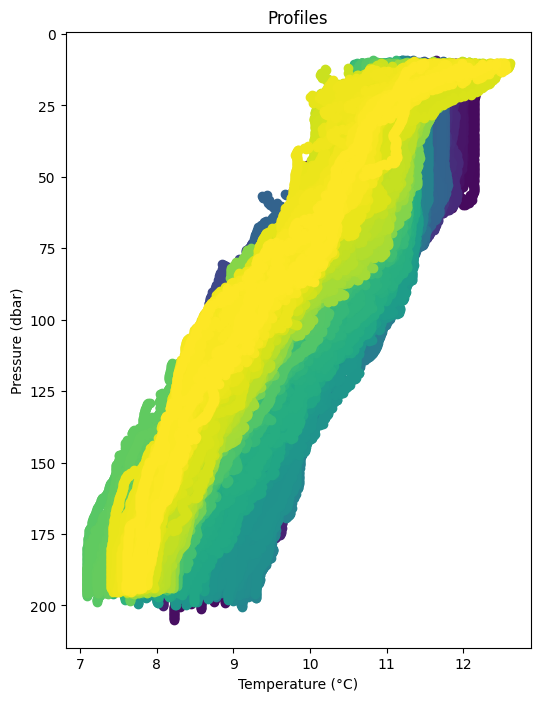

In [76]:
ds_profiles['sea_water_temperature'].compute()
ds_profiles['sea_water_pressure'].compute()

# Extract number of profiles
n_profiles = ds_profiles.dims['profile_number']

# Choose a colormap (e.g., 'viridis', 'plasma', 'gray')
cmap = plt.get_cmap('viridis')

# Scale colors from light to dark
colors = [cmap(i / n_profiles) for i in range(n_profiles)]

plt.figure(figsize=(6, 8))

for i, prof in enumerate(ds_profiles.profile_number.values):
    temp = ds_profiles['sea_water_temperature'].sel(profile_number=prof)
    pres = ds_profiles['sea_water_pressure'].values  # y-axis

    plt.scatter(temp, pres, color=colors[i], label=str(prof))

plt.gca().invert_yaxis()  # pressure increases downward
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (dbar)')
plt.title('Profiles')
plt.show()

In [8]:
import hvplot.xarray

ds_profiles.sea_water_temperature.hvplot.quadmesh(
    x='profile_number',
    y='sea_water_pressure',
    colorbar=True,
    flip_yaxis=True,
    cmap='cmo.thermal',
    width=800,
    height=400
)

NameError: name 'ds_profiles' is not defined

In [3]:
# ds_profiles.corrected_dissolved_oxygen.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.oxy',
#     width=800,
#     height=400
# )

In [68]:
# ds_profiles.sea_water_practical_salinity.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.haline',
#     width=800,
#     height=400
# )

In [69]:
# ds_profiles.sea_water_density.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.dense',
#     width=800,
#     height=400
# )

In [70]:
# ds_profiles.ph_seawater.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.matter',
#     width=800,
#     height=400
# )

In [71]:
# ds_profiles.pco2_seawater.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.matter',
#     width=800,
#     height=400
# )

In [72]:
# ds_profiles.salinity_corrected_nitrate.hvplot.quadmesh(
#     x='profile_number',
#     y='sea_water_pressure',
#     colorbar=True,
#     flip_yaxis=True,
#     cmap='cmo.matter',
#     width=800,
#     height=400
# )